In [1]:
import glob, os
import numpy as np
import geopandas as gpd
import rasterio
import rasterio.mask
import rasterio.plot
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import subprocess
print('All libraries successfully imported!')
print(f'Rasterio : {rasterio.__version__}')

All libraries successfully imported!
Rasterio : 1.4.3


In [2]:
# Set the working directory (replace with the path to your directory)
os.chdir('/export/homes/gujadot/')

# Verify the current working directory
print("Current working directory:", os.getcwd())


Current working directory: /export/store11/homes/gujadot


In [3]:
# Import the function from your Python file
from funcs import s4s_format



In [4]:
# points_file       = f'/export/homes/gujadot/Samoa/data_cleanedV1.gpkg'
# points_file = '/export/projects/Sen4Stat/COUNTRIES/Samoa/2025/windshield/V2/windshieldpoints.gpkg'
points_file = '/export/projects/Sen4Stat/COUNTRIES/Samoa/2025/survey_windshield_cleaned/04262025/windshieldpoints_all.gpkg'
survey_points = '/export/projects/Sen4Stat/COUNTRIES/Samoa/2025/survey_windshield_cleaned/04262025/surveypoints_all.gpkg'
previous_file = '/export/projects/Sen4Stat/COUNTRIES/Samoa/2025/windshield/V2/existing_points.gpkg'
points_clouds_file = '/export/projects/Sen4Stat/COUNTRIES/Samoa/2025/04262025_clouds_points.shp'
polygons_file = f'/export/projects/Sen4Stat/COUNTRIES/Samoa/2025/SURVEY/Surveypolygons.gpkg'
gdf = gpd.read_file(points_file)
gdf_survey = gpd.read_file(survey_points)
gdf_ex = gpd.read_file(previous_file)
clouds = gpd.read_file(points_clouds_file)
polygons = gpd.read_file(polygons_file)

/opt/modules/python_libs/lib64/python3.11/site-packages/pyogrio/geopandas.py:261: UserWarning: More than one layer found in 'existing_points.gpkg': 'windshieldpoints_6f555f92_2750_4f29_9ee4_d294aacf8d5f' (default), 'log_indices', 'log_layer_ids', 'log_fids', 'log_added_attrs', 'log_added_features', 'log_removed_features', 'log_feature_updates', 'log_geometry_updates'. Specify layer parameter to avoid this warning.
  result = read_func(


In [5]:
# Define target CRS
target_crs = "EPSG:32702"

# Reproject all to the target CRS
gdf = gdf.to_crs(target_crs)
gdf_survey = gdf_survey.to_crs(target_crs)
gdf_ex = gdf_ex.to_crs(target_crs)
clouds = clouds.to_crs(target_crs)
polygons = polygons.to_crs(target_crs)

In [6]:
# gdf.explore()

In [7]:
gdf = gdf[gdf['Crop'].notna()]
gdf_ex = gdf_ex[gdf_ex['Crop'].notna()]

In [8]:
Crop_gdf = gdf[gdf['Crop'] != '9999']
Noncrop_gdf = gdf[gdf['Crop'] == '9999']

Crop_gdf_ex = gdf_ex[gdf_ex['Crop'] != '9999']
Noncrop_gdf_ex = gdf_ex[gdf_ex['Crop'] == '9999']

In [9]:
Crop_gdf.columns

Index(['id', 'ID_enu', 'Date', 'Crop', 'NonCrop', 'Comment', 'Picture1',
       'Picture2', 'layer', 'path', 'geometry'],
      dtype='object')

### The points from the survey had the 'mixed' possibility, quality check for that

In [10]:
gdf_survey = gdf_survey.rename(columns={'crop':'Crop', 'noncrop':'NonCrop'})

In [11]:
Crop_gdf_survey_mixed = gdf_survey[(gdf_survey['Crop'] != '9999') & (gdf_survey['Mixed'] == '1')]
# Noncrop_gdf_survey = gdf_survey[gdf_survey['crop'] == '9999']
# Crop_gdf_survey_mixed

#### 38 mixed values have 0 as label (Other crops). Ofthen, it is mixed with Forest, water or othercrops. Those point are thus removed.

In [12]:
Crop_gdf_survey_mixed['Crop'].value_counts()



Crop
2133    52
2419    38
0       38
2417    18
1111    16
1121    13
2416     5
Name: count, dtype: int64

#### 37 points are mixed but we don't know with what

In [13]:
Crop_gdf_survey_mixed['MixedType'].isna().sum()

37

#### All remaining mixed points are grouped in 1 class == 2132 to be consistent with the points from the existing.gpkg (taken by guy) + the windshield class

In [14]:
# Remove points where Crop == 0
removed_rows = Crop_gdf_survey_mixed.shape[0] - Crop_gdf_survey_mixed[Crop_gdf_survey_mixed['Crop'] != '0'].shape[0]
Crop_gdf_survey_mixed = Crop_gdf_survey_mixed[Crop_gdf_survey_mixed['Crop'] != '0']
print(f"{removed_rows} rows were removed where Crop == '0'")
# Rename all remaining Crop values to '2132'
Crop_gdf_survey_mixed['Crop'] = '2132'

38 rows were removed where Crop == '0'


In [15]:
# sanity check
Crop_gdf_survey_mixed['Crop'].value_counts()


Crop
2132    142
Name: count, dtype: int64

### remaining survey points

In [16]:
Crop_gdf_survey_remaining_crop = gdf_survey[(gdf_survey['Crop'] != '9999') & (gdf_survey['Mixed'] != '1')]
Crop_gdf_survey_remaining_noncrop = gdf_survey[(gdf_survey['Crop'] == '9999') & (gdf_survey['Mixed'] != '1')]

In [17]:
Crop_gdf_survey_mixed.columns

Index(['district_id', 'village_id', 'ea_code', 'Parcel_id', 'Crop', 'NonCrop',
       'yield', 'yield_unit', 'Household', 'Mixed', 'MixedType', 'MixedRatio',
       'region_id', 'Comment', 'Picture1', 'Picture2', 'layer', 'path',
       'geometry'],
      dtype='object')

In [18]:
Crop_gdf.columns

Index(['id', 'ID_enu', 'Date', 'Crop', 'NonCrop', 'Comment', 'Picture1',
       'Picture2', 'layer', 'path', 'geometry'],
      dtype='object')

In [19]:
Crop_gdf_ex.columns

Index(['fid', 'id', 'ID_enu', 'Date', 'Crop', 'NonCrop', 'Comment', 'Picture1',
       'Picture2', 'geometry'],
      dtype='object')

### Droping uncessary columns from gdf / gdf_ex and gdf_survey

In [20]:
columns_to_drop_crop = ['id', 'ID_enu', 'Date', 'NonCrop', 'Comment', 'Picture1', 'Picture2']
columns_to_drop_noncrop = ['id', 'ID_enu', 'Date', 'Crop', 'Comment', 'Picture1', 'Picture2']

Crop_gdf = Crop_gdf.drop(columns=columns_to_drop_crop)
Noncrop_gdf = Noncrop_gdf.drop(columns=columns_to_drop_noncrop)

Crop_gdf = Crop_gdf.drop(columns=['layer','path'])
Noncrop_gdf = Noncrop_gdf.drop(columns=['layer','path'])

Crop_gdf_ex = Crop_gdf_ex.drop(columns=columns_to_drop_crop)
Noncrop_gdf_ex = Noncrop_gdf_ex.drop(columns=columns_to_drop_noncrop)

Crop_gdf_ex = Crop_gdf_ex.drop(columns=['fid'])
Noncrop_gdf_ex = Noncrop_gdf_ex.drop(columns=['fid'])


In [21]:
columns_to_drop_crop_survey = ['district_id', 'village_id', 'ea_code', 'Parcel_id', 'NonCrop',
       'yield', 'yield_unit', 'Household', 'Mixed', 'MixedType', 'MixedRatio',
       'region_id', 'Comment', 'Picture1', 'Picture2', 'layer', 'path',
       ]
columns_to_drop_noncrop_survey = ['district_id', 'village_id', 'ea_code', 'Parcel_id', 'Crop',
       'yield', 'yield_unit', 'Household', 'Mixed', 'MixedType', 'MixedRatio',
       'region_id', 'Comment', 'Picture1', 'Picture2', 'layer', 'path',
       ]

Crop_gdf_survey_mixed = Crop_gdf_survey_mixed.drop(columns=columns_to_drop_crop_survey)
Crop_gdf_survey_remaining_crop = Crop_gdf_survey_remaining_crop.drop(columns=columns_to_drop_crop_survey)
Crop_gdf_survey_remaining_noncrop = Crop_gdf_survey_remaining_noncrop.drop(columns=columns_to_drop_noncrop_survey)

In [22]:
Crop_gdf_survey_mixed.columns

Index(['Crop', 'geometry'], dtype='object')

In [23]:
Crop_gdf_survey_remaining_crop.columns

Index(['Crop', 'geometry'], dtype='object')

In [24]:
Crop_gdf_survey_remaining_noncrop.columns

Index(['NonCrop', 'geometry'], dtype='object')

In [25]:
Crop_gdf = Crop_gdf.rename(columns={'Crop': 'crop_code'})
Noncrop_gdf = Noncrop_gdf.rename(columns={'NonCrop': 'crop_code'})
Crop_gdf_ex = Crop_gdf_ex.rename(columns={'Crop': 'crop_code'})
Noncrop_gdf_ex = Noncrop_gdf_ex.rename(columns={'NonCrop': 'crop_code'})
Crop_gdf_survey_mixed = Crop_gdf_survey_mixed.rename(columns={'Crop': 'crop_code'})
Crop_gdf_survey_remaining_crop = Crop_gdf_survey_remaining_crop.rename(columns={'Crop': 'crop_code'})
Crop_gdf_survey_remaining_noncrop = Crop_gdf_survey_remaining_noncrop.rename(columns={'NonCrop': 'crop_code'})

### Before concat the 3 gdf, let's add the data from the polygons (taking the centroid) to add more points for the training

In [26]:
polygons.columns

Index(['district_id', 'village_id', 'ea_code', 'Parcel_id', 'crop', 'noncrop',
       'yield', 'yield_unit', 'Household', 'Mixed', 'MixedType', 'MixedRatio',
       'region_id', 'Comment', 'Picture1', 'Picture2', 'geometry'],
      dtype='object')

In [27]:
# Not taking the non crop here as there are only 3 noncrop
polygons_crop = polygons[polygons['crop'] != '9999']



In [28]:
columns_to_drop_polygons_crop = ['district_id', 'village_id', 'ea_code', 'Parcel_id','noncrop',
       'yield', 'yield_unit', 'Household', 'Mixed', 'MixedType', 'MixedRatio',
       'region_id', 'Comment', 'Picture1', 'Picture2']

polygons_crop = polygons_crop.drop(columns=columns_to_drop_polygons_crop)


In [29]:
polygons_crop = polygons_crop.rename(columns={'crop':'crop_code'})

### taking the centroid of the polygons 

In [30]:
# Take centroids of polygons_crop and keep only rows with a crop_code
polygons_crop_centroid = polygons_crop.copy()

if polygons_crop_centroid.crs != 'EPSG:32702':
    polygons_crop_centroid = polygons_crop_centroid.to_crs('EPSG:32702')
    
# Fix any invalid geometries, then compute centroids
polygons_crop_centroid['geometry'] = polygons_crop_centroid.geometry.buffer(0)
polygons_crop_centroid['geometry'] = polygons_crop_centroid.geometry.centroid

# drop polygons without a crop_code (keep only those that will be useful as training points)
polygons_crop_centroid = polygons_crop_centroid[polygons_crop_centroid['crop_code'].notna()].reset_index(drop=True)

print(f"Centroids computed: {len(polygons_crop_centroid)} features (dropped {len(polygons_crop) - len(polygons_crop_centroid)} without crop_code).")
polygons_crop_centroid.head()

Centroids computed: 261 features (dropped 4 without crop_code).


,crop_code,geometry
0,2419,POINT (417107.735 8470947.361)
1,2419,POINT (417104.089 8470619.122)
2,2417,POINT (417147.984 8470957.391)
3,2417,POINT (412121.739 8473045.978)
4,0,POINT (412107.312 8473101.706)


### Concat the 4 sources of information (+ the clouds)

In [31]:
gdf_all = pd.concat([Crop_gdf, Noncrop_gdf, Crop_gdf_ex, Noncrop_gdf_ex, Crop_gdf_survey_mixed, Crop_gdf_survey_remaining_crop, Crop_gdf_survey_remaining_noncrop, clouds, polygons_crop_centroid], ignore_index=True)

In [32]:
gdf_all

,crop_code,geometry
0,1111,POINT (365157.804 8480729.255)
1,1111,POINT (365183.577 8480735.61)
2,1121,POINT (365158.559 8480779.379)
3,2417,POINT (361669.853 8479325.57)
4,1111,POINT (360966.78 8478571.387)
...,...,...
5506,2133,POINT (411566.217 8469979.248)
5507,2133,POINT (411544.075 8469912.932)
5508,1111,POINT (435714.391 8461902.347)
5509,1111,POINT (434993.156 8460723.513)


In [33]:
print(f'there are {gdf_all.isna().sum()} missing values in the dataframe')
gdf_all = gdf_all.dropna()

there are crop_code    237
geometry       0
dtype: int64 missing values in the dataframe


In [34]:
gdf_all

,crop_code,geometry
0,1111,POINT (365157.804 8480729.255)
1,1111,POINT (365183.577 8480735.61)
2,1121,POINT (365158.559 8480779.379)
3,2417,POINT (361669.853 8479325.57)
4,1111,POINT (360966.78 8478571.387)
...,...,...
5506,2133,POINT (411566.217 8469979.248)
5507,2133,POINT (411544.075 8469912.932)
5508,1111,POINT (435714.391 8461902.347)
5509,1111,POINT (434993.156 8460723.513)


### survey mapping legend

In [35]:
gdf_all['crop_code'].unique()

array(['1111', '1121', '2417', '2133', '2416', '2419', '0', '1111\n', '6',
       '5', '9', '1', '3', '8', '7', '2132', '2136', '9121', 9311, 9214],
      dtype=object)

In [36]:
gdf_all[gdf_all['crop_code'] == '1111\n'].value_counts()

crop_code  geometry                     
1111\n     POINT (417149.79 8471043.334)    2
           POINT (417136.14 8471041.175)    1
           POINT (417140.462 8471043.16)    1
Name: count, dtype: int64

In [37]:
gdf_all['crop_code'] = gdf_all['crop_code'].replace('1111\n', '1111')

/opt/modules/python_libs/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [38]:
gdf_all['crop_code'].unique()

array(['1111', '1121', '2417', '2133', '2416', '2419', '0', '6', '5', '9',
       '1', '3', '8', '7', '2132', '2136', '9121', 9311, 9214],
      dtype=object)

In [39]:
import pandas as pd

Crop_code_mapping = {
    0: 'Other crops',
    1111: 'Taro',
    1121: 'Taamu',
    2132: 'Mix crops (banana, taro, coconut, etc)',
    2133: 'Banana',
    2136: 'Coffee',
    2416: 'Breadfruit',
    2417: 'Coconut',
    2419: 'Cocoa',
    9999: 'Noncrop'}

Non_crop_code_mapping = {
    3: 'Grassland',
    6: 'Forest',
    5: 'Shrubland',
    7: 'Bare soil',
    8: 'Built-up area',
    9: 'Water',
    1: 'Sand',
    9121: 'Seashore',
    9311: 'Clouds',
    9214: 'Cloud shadows'}

# # Convert the mapping dictionaries to DataFrames
# crop_df = pd.DataFrame(list(Crop_code_mapping.items()), columns=['Code', 'Description'])
# crop_df['Type'] = 'Crop'

# noncrop_df = pd.DataFrame(list(Non_crop_code_mapping.items()), columns=['Code', 'Description'])
# noncrop_df['Type'] = 'NonCrop'

# # Concatenate both DataFrames
# mapping_df = pd.concat([crop_df, noncrop_df], ignore_index=True)

# # Save to Excel file
# mapping_df.to_excel('Samoa/crop_code_mapping.xlsx', index=False)

In [40]:
gdf_all['crop_code'] = pd.to_numeric(gdf_all['crop_code'], errors='coerce').astype('Int64')


/opt/modules/python_libs/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [41]:
combined_mapping = {**Crop_code_mapping, **Non_crop_code_mapping}

# Make sure crop_code is int (if possible)
gdf_all['crop_code'] = gdf_all['crop_code'].astype(int, errors='ignore')

# Apply mapping safely
gdf_all['crop_label'] = gdf_all['crop_code'].map(combined_mapping).fillna(gdf_all['crop_code'])

# Check results
gdf_all.head()


/opt/modules/python_libs/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/modules/python_libs/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,crop_code,geometry,crop_label
0,1111,POINT (365157.804 8480729.255),Taro
1,1111,POINT (365183.577 8480735.61),Taro
2,1121,POINT (365158.559 8480779.379),Taamu
3,2417,POINT (361669.853 8479325.57),Coconut
4,1111,POINT (360966.78 8478571.387),Taro


In [42]:
gdf_all['crop_code'].unique()

array([1111, 1121, 2417, 2133, 2416, 2419,    0,    6,    5,    9,    1,
          3,    8,    7, 2132, 2136, 9121, 9311, 9214])

### S4S mapping

In [43]:
Non_crop_code_mapping = {
    3113: 'Grassland',
    5111: 'Shrubland',
    6999: 'Forest',
    7211: 'Bare soil',
    8111: 'Built-up area',
    9111: 'Water',
    9121: 'Seashore',
    8511: 'Sand',
    9311: 'Clouds',
    9214: 'Cloud shadows'}

Crop_code_mapping = {
    1192: 'Other crops',
    1111: 'Taro',
    2132: 'Mix crops (banana, taro, coconut, etc)',
    1121: 'Taamu',
    2133: 'Banana',
    2136: 'Coffee',
    2416: 'Breadfruit',
    2417: 'Coconut',
    2419: 'Cocoa'}

In [44]:
gdf_all['crop_label'] = gdf_all['crop_label'].astype(str)

/opt/modules/python_libs/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [45]:
combined_mapping = {**Crop_code_mapping, **Non_crop_code_mapping}
# Reverse the mapping: label → code
reverse_mapping = {v: k for k, v in combined_mapping.items()}
# Map crop_label back to numeric crop_code
gdf_all['crop_code'] = gdf_all['crop_label'].map(reverse_mapping)#.fillna(gdf_all['crop_code'])
#gdf_all = gdf_all.drop(columns=['crop_label'])
gdf_all.head()

/opt/modules/python_libs/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,crop_code,geometry,crop_label
0,1111,POINT (365157.804 8480729.255),Taro
1,1111,POINT (365183.577 8480735.61),Taro
2,1121,POINT (365158.559 8480779.379),Taamu
3,2417,POINT (361669.853 8479325.57),Coconut
4,1111,POINT (360966.78 8478571.387),Taro


In [46]:
gdf_all['crop_code'].unique()

array([1111, 1121, 2417, 2133, 2416, 2419, 1192, 6999, 5111, 9111, 8511,
       3113, 8111, 7211, 2132, 2136, 9121, 9311, 9214])

In [47]:
print(gdf_all.crs)

EPSG:32702


In [48]:
print(gdf_all['crop_code'].value_counts())

crop_code
6999    1005
2133     878
2417     820
1111     563
3113     351
2419     302
9111     221
2416     200
5111     198
1192     192
2132     163
8111     135
1121     101
9121      75
9311      31
8511      19
9214      12
7211       7
2136       1
Name: count, dtype: int64


In [49]:
# gdf_all = gdf_all[~gdf_all['crop_code'].isin([7211, 2136])]
gdf_all = gdf_all[~gdf_all['crop_code'].isin([2136])] # removing 2136 (coffee) class as there is only one point (minimum 5 for smote)

In [102]:
# # Flag duplicate geometries
# gdf_all['is_duplicate_geometry'] = gdf_all.duplicated(subset=['geometry'], keep=False)
# duplicates = gdf_all.loc[gdf_all['is_duplicate_geometry'], ['geometry']].copy()
# # unique group number to each duplicate geometry
# duplicates['geometry_group'] = pd.factorize(duplicates['geometry'])[0] + 1
# # Merge group numbers back
# gdf_all = gdf_all.merge(
#     duplicates[['geometry', 'geometry_group']],
#     on='geometry',
#     how='left'
# )

# print("Number of duplicate geometries:", gdf_all['is_duplicate_geometry'].sum())
# print(gdf_all[['geometry', 'is_duplicate_geometry', 'geometry_group']].head())
# gdf_all


In [50]:
print(f"Number of rows before dropping duplicate geometries: {len(gdf_all)}")
gdf_all = gdf_all.drop_duplicates(subset=['geometry'])
print(f"Number of rows after dropping duplicate geometries: {len(gdf_all)}")

Number of rows before dropping duplicate geometries: 5273
Number of rows after dropping duplicate geometries: 4609


In [51]:
print(gdf_all['crop_code'].value_counts())

crop_code
6999    879
2133    757
2417    689
1111    505
3113    328
2419    280
5111    177
9111    166
1192    162
2416    162
2132    137
8111    135
1121     89
9121     75
9311     31
8511     18
9214     12
7211      7
Name: count, dtype: int64


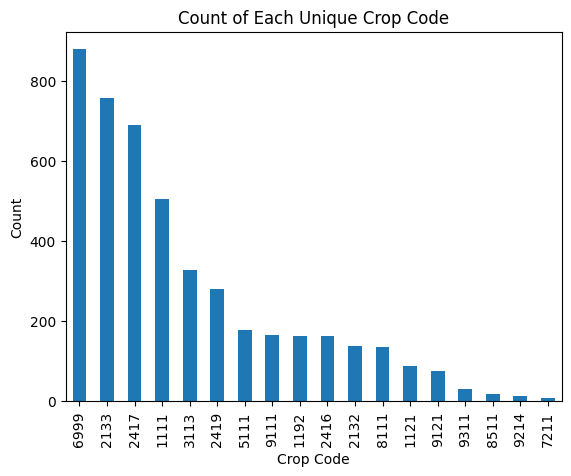

In [52]:
crop_counts = gdf_all['crop_code'].value_counts()
crop_counts.plot(kind='bar')
plt.xlabel('Crop Code')
plt.ylabel('Count')
plt.title('Count of Each Unique Crop Code')
plt.show()

### Keep points that are inside the VHR ROI

In [55]:
ROI_1_file = '/export/projects/Sen4Stat/COUNTRIES/Samoa/2025/aoi_west.gpkg'
ROI_1 = gpd.read_file(ROI_1_file)
print(f"ROI CRS: {ROI_1.crs}")

ROI_1 = ROI_1.to_crs(target_crs)
print(f"ROI CRS: {ROI_1.crs}")


ROI CRS: EPSG:4326
ROI CRS: EPSG:32702


In [56]:
gdf_all_roi = gdf_all[gdf_all.within(ROI_1.unary_union)]
print(f"Number of points inside ROI_1: {len(gdf_all_roi)}")
gdf_all_roi.head()

Number of points inside ROI_1: 1866


/tmp/ipykernel_33406/2445685712.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_all_roi = gdf_all[gdf_all.within(ROI_1.unary_union)]


,crop_code,geometry,crop_label
205,2419,POINT (411519.095 8472489.945),Cocoa
206,2133,POINT (411651.731 8472792.901),Banana
246,2417,POINT (410567.619 8469545.201),Coconut
247,2133,POINT (410635.465 8469288.128),Banana
248,2417,POINT (410623.394 8469635.246),Coconut


In [57]:
print(gdf_all_roi['crop_code'].value_counts())

crop_code
2133    401
2417    287
6999    251
2419    225
1111    119
2132    108
5111     76
3113     75
8111     72
1192     57
1121     53
2416     50
9121     32
9311     31
9214     12
9111     10
7211      6
8511      1
Name: count, dtype: int64


In [58]:
gdf_all_roi = gdf_all_roi[~gdf_all_roi['crop_code'].isin([8511])] # removing the only sand point

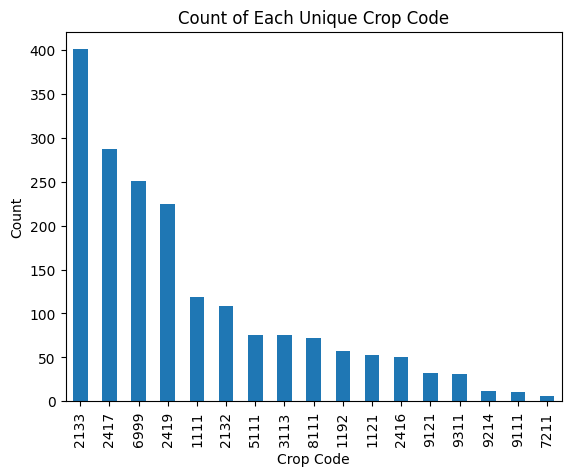

In [59]:
crop_counts = gdf_all_roi['crop_code'].value_counts()
crop_counts.plot(kind='bar')
plt.xlabel('Crop Code')
plt.ylabel('Count')
plt.title('Count of Each Unique Crop Code')
plt.show()

In [60]:
gdf_all_roi.to_file('/export/projects/Sen4Stat/COUNTRIES/Samoa/2025/survey_windshield_cleaned/04262025/gdf_all_04262025_V2', driver='GPKG')
print(f"GeoDataFrame exported")

GeoDataFrame exported


/opt/modules/python_libs/lib64/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: The filename extension should be 'gpkg' instead of '' to conform to the GPKG specification.
  ogr_write(


In [61]:
# Reproject to EPSG:32702 if not already
if gdf_all_roi.crs != 'EPSG:32702':
    gdf_all_roi = gdf_all_roi.to_crs('EPSG:32702')

# Buffer points so diameter = 2m (radius = 1m)
gdf_all_roi_buffered = gdf_all_roi.copy()
gdf_all_roi_buffered['geometry'] = gdf_all_roi_buffered.geometry.buffer(1)

gdf_all_roi_buffered.head()

,crop_code,geometry,crop_label
205,2419,"POLYGON ((411520.095 8472489.945, 411520.09 84...",Cocoa
206,2133,"POLYGON ((411652.731 8472792.901, 411652.726 8...",Banana
246,2417,"POLYGON ((410568.619 8469545.201, 410568.614 8...",Coconut
247,2133,"POLYGON ((410636.465 8469288.128, 410636.46 84...",Banana
248,2417,"POLYGON ((410624.394 8469635.246, 410624.389 8...",Coconut


In [62]:
gdf_all_roi_buffered.to_file('/export/projects/Sen4Stat/COUNTRIES/Samoa/2025/survey_windshield_cleaned/04262025/gdf_all_buffered_04262025_V2', driver='GPKG')
print(f"GeoDataFrame exported")

GeoDataFrame exported


/opt/modules/python_libs/lib64/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: The filename extension should be 'gpkg' instead of '' to conform to the GPKG specification.
  ogr_write(


### End here for the dataset of the VHR

### Sen4Stat format

In [ ]:
# Check if the geometry is projected (it has to be for the function to work)
# EPSG:4326 is WGS 84 and is a geographic CRS (in degrees, thus buffer not possible)
if not gdf_all.crs.is_projected:
    print(f'Geometry is not projected. Current CRS is {gdf_all.crs}. Reprojecting...')
    
    # Define the projected CRS EPSG 32644 is for UTM 44N for south asia //// EPSG:32642 is for UTM 42N for tajikistan (western part) //// EPSG:32643 is for UTM 43N for the Maldives /// EPSG:32735
    # EPSG:32702 is for UTM 2S for Samoa
    projected_crs = 'EPSG:32702'  # EPSG:4326 is WGS 84 and mandatory for Sen4Stat
    
    # Reproject the GeoDataFrame
    #geo_gdf = gdf.loc[:, ['geometry']]
    gdf_all = gdf_all.to_crs(projected_crs)
    print(f'Reprojected GeoDataFrame to {projected_crs}.')
else:
    print('Geometry is already in a projected CRS.')


In [ ]:
# Call the function to check and format the shapefile
year = 2025
#points = True
data, geometry = s4s_format(gdf_all, year)

# Check if the function ran successfully
if data is not None and geometry is not None:
    print("Shapefile formatted successfully!")
    print(data.head())      # Display the first few rows of the data
    print(geometry.head())  # Display the first few rows of the geometry
else:
    print("There was an issue with formatting.")

In [ ]:
year = '2025'
version = '3'
country = 'Samoa'
site = 'Upolu'

base_dir = f'/export/projects/Sen4Stat/COUNTRIES/{country}/{year}/IN_SITU/{site}/V{version}/S4S_Format/'
Path(base_dir).mkdir(parents=True, exist_ok=True)
print(f"Directory created: {base_dir}")

In [ ]:
output_csv = f'{base_dir}Samoa_data_V{version}.csv'

data.to_csv(output_csv, index=False)
print(f"GeoDataFrame exported to {output_csv}")

In [ ]:
output_shp = f'{base_dir}Samoa_geometry_V{version}.shp'

geometry.to_file(output_shp, driver='ESRI Shapefile')
print(f"Geometry exported to {output_shp}")